In [1]:
!pip install statsforecast shap xgboost utilsforecast


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from statsforecast.models import MSTL, AutoARIMA

import os
os.environ["NIXTLA_ID_AS_COL"] = "true"

In [3]:
def rescale_using_MAD(train_df, multiplier=3):
    train_df_mad = train_df.copy()
    median = train_df_mad["y"].median()
    mad = (train_df_mad["y"] - median).abs().median()
    threshold = multiplier * mad
    train_df_mad.loc[(train_df_mad["y"] - median).abs() > threshold, "y"] = median
    return train_df_mad

def create_train_dev_splits(train_df, dev_df, gt_df, start_date, window_size):
    pass_gt_dev = gt_df[gt_df["ds"] < start_date]
    window_train = window_size - len(pass_gt_dev)
    pass_gt = pd.concat([train_df.tail(window_train), pass_gt_dev])
    dev_dataset = dev_df[dev_df["ds"] >= start_date]
    gt_dataset = gt_df[gt_df["ds"] >= start_date]
    return pass_gt, dev_dataset, gt_dataset

In [4]:
ptcw2022_oh = pd.read_csv("ptcw2022_oh.csv")
ptc_weather_2023_dev_oh = pd.read_csv("ptc_weather_2023_dev_oh.csv")
ptc_weather_2023_ground_truth_oh = pd.read_csv("ptc_weather_2023_ground_truth_oh.csv")

ptcw2022_oh["ds"] = pd.to_datetime(ptcw2022_oh["ds"])
ptc_weather_2023_dev_oh["ds"] = pd.to_datetime(ptc_weather_2023_dev_oh["ds"])
ptc_weather_2023_ground_truth_oh["ds"] = pd.to_datetime(ptc_weather_2023_ground_truth_oh["ds"])

print("2022:", ptcw2022_oh.shape)
print("2023 dev:", ptc_weather_2023_dev_oh.shape)
print("2023 ground truth:", ptc_weather_2023_ground_truth_oh.shape)

2022: (8733, 21)
2023 dev: (8735, 20)
2023 ground truth: (8735, 21)


In [5]:
# Using January 2023 evaluation point — same as retrain_eval_loop
start_date = pd.Timestamp("2023-01-16 00:00:00")

loop_train_df, loop_dev_df, loop_gt_df = create_train_dev_splits(
    train_df=ptcw2022_oh,
    dev_df=ptc_weather_2023_dev_oh,
    gt_df=ptc_weather_2023_ground_truth_oh,
    start_date=start_date,
    window_size=len(ptcw2022_oh)
)

# MAD cleaning
loop_train_df = rescale_using_MAD(loop_train_df, multiplier=3)

# StandardScaler — fit on train, apply to dev and gt
# Store the scaler so the wrapper can use it later
weather_cols = [
    'temp_mean', 'humidity_mean', 'precipitation_mean', 'rain_mean',
    'snowfall_mean', 'snow_depth_mean', 'wind_speed_mean', 'cloud_cover_mean',
    'cloud_cover_low_mean', 'cloud_cover_mid_mean', 'cloud_cover_high_mean'
]
scaler = StandardScaler()
loop_train_df = loop_train_df.copy()
loop_dev_df = loop_dev_df.copy()
loop_gt_df = loop_gt_df.copy()

loop_train_df[weather_cols] = scaler.fit_transform(loop_train_df[weather_cols])
loop_dev_df[weather_cols] = scaler.transform(loop_dev_df[weather_cols])
loop_gt_df[weather_cols] = scaler.transform(loop_gt_df[weather_cols])

print(f"Training rows: {len(loop_train_df)} | Dev rows: {len(loop_dev_df)}")

Training rows: 8733 | Dev rows: 8375


In [6]:
import time

print("Fitting MSTL+AutoARIMA... (this takes a few minutes)")
sf = StatsForecast(
    models=[MSTL(
        season_length=[24, 24*7],
        trend_forecaster=AutoARIMA()
    )],
    freq='1h',
    n_jobs=1
)

t0 = time.time()
sf.fit(df=loop_train_df)
print(f"MSTL fitted in {round(time.time()-t0, 1)}s")

Fitting MSTL+AutoARIMA... (this takes a few minutes)
MSTL fitted in 66.5s


In [7]:
HORIZON = 8

# Exogenous feature columns MSTL uses — no hour/month, MSTL handles those internally
exog_cols = [
    'temp_mean', 'humidity_mean', 'precipitation_mean', 'rain_mean',
    'snowfall_mean', 'snow_depth_mean', 'wind_speed_mean', 'cloud_cover_mean',
    'cloud_cover_low_mean', 'cloud_cover_mid_mean', 'cloud_cover_high_mean',
    'is_holiday',
    'day_of_week_1', 'day_of_week_2', 'day_of_week_3',
    'day_of_week_4', 'day_of_week_5', 'day_of_week_6'
]

# Template: provides correct ds and unique_id for sf.predict()
# KernelSHAP only perturbs the exog feature values, timestamps stay fixed
X_template = loop_dev_df[['ds', 'unique_id'] + exog_cols].head(HORIZON).copy()

# Time one prediction call to estimate total KernelSHAP runtime
t0 = time.time()
test_pred = sf.predict(h=HORIZON, X_df=X_template)
single_call_time = round(time.time() - t0, 3)
print(f"Single sf.predict() call: {single_call_time}s")

# Estimate: KernelSHAP with nsamples=100, 20 test scenarios
# makes roughly 100 * 20 model calls
estimated_minutes = round((100 * 20 * single_call_time) / 60, 1)
print(f"Estimated KernelSHAP runtime: ~{estimated_minutes} minutes")
print(test_pred)

Single sf.predict() call: 0.006s
Estimated KernelSHAP runtime: ~0.2 minutes
     unique_id                  ds         MSTL
0  all_sensors 2023-01-16 00:00:00   272.316895
1  all_sensors 2023-01-16 01:00:00   125.521713
2  all_sensors 2023-01-16 02:00:00    -0.329913
3  all_sensors 2023-01-16 03:00:00   164.189468
4  all_sensors 2023-01-16 04:00:00   304.204071
5  all_sensors 2023-01-16 05:00:00   956.057312
6  all_sensors 2023-01-16 06:00:00  2568.870361
7  all_sensors 2023-01-16 07:00:00  2817.561523


In [9]:
# def mstl_predict(X_array):
#     """
#     KernelSHAP wrapper around sf.predict().

#     Input:  X_array shape (n_perturbed, n_exog_features)
#             Each row is a perturbed set of exogenous feature values.
#             KernelSHAP calls this hundreds of times with different perturbations.

#     Output: array shape (n_perturbed,)
#             Mean MSTL forecast over the 8-hour window for each perturbed input.

#     The same perturbed vector is broadcast across all 8 forecast hours.
#     This answers: "if these weather/calendar conditions persist,
#                    how does each feature shift the average forecast?"
#     """
#     results = []
#     for row in X_array:
#         X_df_temp = X_template.copy()
#         for j, col in enumerate(exog_cols):
#             X_df_temp[col] = row[j]
#         try:
#             preds = sf.predict(h=HORIZON, X_df=X_df_temp)
#             results.append(preds['MSTL'].mean())
#         except Exception:
#             # Fallback for extreme perturbations that break the model
#             results.append(np.nan)
#     return np.array(results)

# # Background: compress training exog features to 50 cluster centers
# # This represents "typical" conditions the model was trained on
# # shap.kmeans is much faster than using all 8000+ training rows as background
# print("Computing background cluster centers...")
# background = shap.kmeans(loop_train_df[exog_cols].values, 50)
# print("Background ready.")

# # Test samples: 20 non-overlapping 8-hour forecast scenarios from dev data
# # Sampling every 8 hours gives independent, non-redundant windows
# N_TEST = 20
# test_X = np.array([
#     loop_dev_df[exog_cols].iloc[i].values
#     for i in range(0, N_TEST * HORIZON, HORIZON)
#     if i + HORIZON <= len(loop_dev_df)
# ])[:N_TEST]

# print(f"Test scenarios shape: {test_X.shape}")

Computing background cluster centers...
Background ready.
Test scenarios shape: (20, 18)


In [10]:
def make_wrapper(h_idx):
    def predict_fn(X_array):
        results = []
        for row in X_array:
            X_df_temp = X_template.copy()
            # Perturb only hour h_idx, keep all other hours at actual values
            for j, col in enumerate(exog_cols):
                X_df_temp.iloc[h_idx, X_df_temp.columns.get_loc(col)] = row[j]
            try:
                preds = sf.predict(h=HORIZON, X_df=X_df_temp)
                results.append(preds['MSTL'].iloc[h_idx])
            except Exception:
                results.append(np.nan)
        return np.array(results)
    return predict_fn

# Test samples: actual features at the first hour of each forecast window
# (not broadcast mean — each scenario uses real feature values)
N_TEST = 20
test_X_h1 = np.array([
    loop_dev_df[exog_cols].iloc[i * HORIZON].values
    for i in range(N_TEST)
    if i * HORIZON < len(loop_dev_df)
])[:N_TEST]

print(f"Test scenarios shape: {test_X_h1.shape}")
print("Computing KMeans background...")
background = shap.kmeans(loop_train_df[exog_cols].values, 50)
print("Background ready.")

Test scenarios shape: (20, 18)
Computing KMeans background...
Background ready.


In [ ]:
print("Running robust KernelSHAP across all 8 forecast hours...")
print("This runs 8 separate KernelSHAP passes — expect 8x longer than before.")

all_shap = []
for h_idx in range(HORIZON):
    print(f"  Hour {h_idx + 1}/8...")
    exp = shap.KernelExplainer(make_wrapper(h_idx), background)
    sv = exp.shap_values(test_X_h1, nsamples=100)
    all_shap.append(sv)

# Average SHAP values across all 8 forecast hours
shap_values_accurate = np.mean(all_shap, axis=0)
print("Done.")

Running robust KernelSHAP across all 8 forecast hours...
This runs 8 separate KernelSHAP passes — expect 8x longer than before.
  Hour 1/8...


  0%|          | 0/20 [00:00<?, ?it/s]

  Hour 2/8...


  0%|          | 0/20 [00:00<?, ?it/s]

  Hour 3/8...


  0%|          | 0/20 [00:00<?, ?it/s]

  Hour 4/8...


  0%|          | 0/20 [00:00<?, ?it/s]

  Hour 5/8...


  0%|          | 0/20 [00:00<?, ?it/s]

In [11]:
np.save("shap_values_accurate.npy", shap_values_accurate)
np.save("test_X_h1.npy", test_X_h1)

Saved. To reload later:
  shap_values = np.load('shap_values_mstl.npy')
  test_X      = np.load('test_X_mstl.npy')


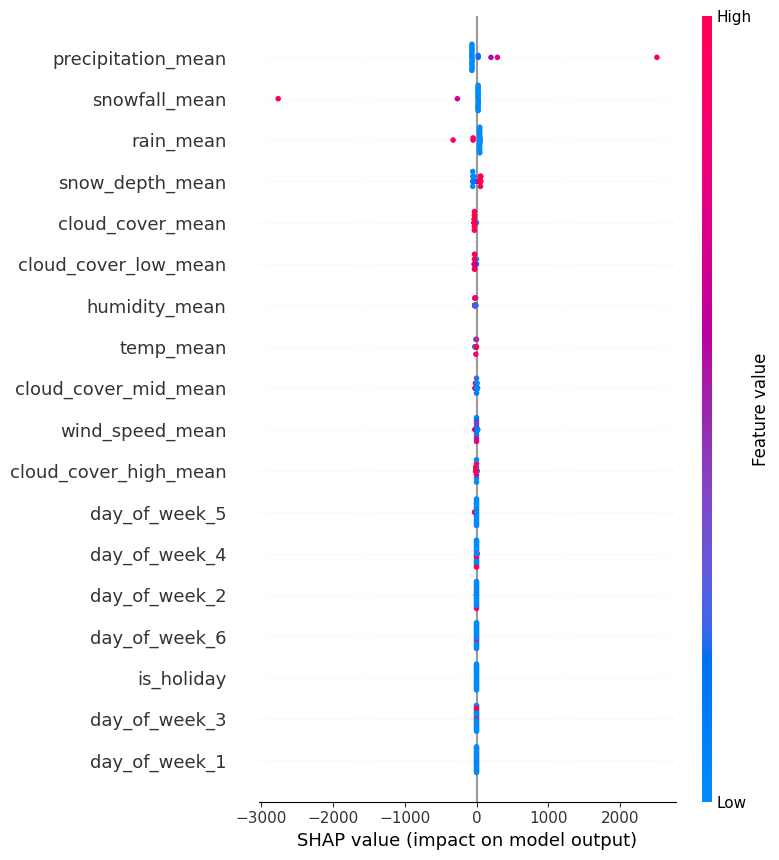

In [12]:
# Each dot = one forecast scenario
# X-axis: SHAP value (positive = pushes forecast up, negative = pushes down)
# Color: Red = high feature value, Blue = low feature value
plt.figure()
shap.summary_plot(
    shap_values_accurate,
    test_X_h1,
    feature_names=exog_cols,
    show=True
)

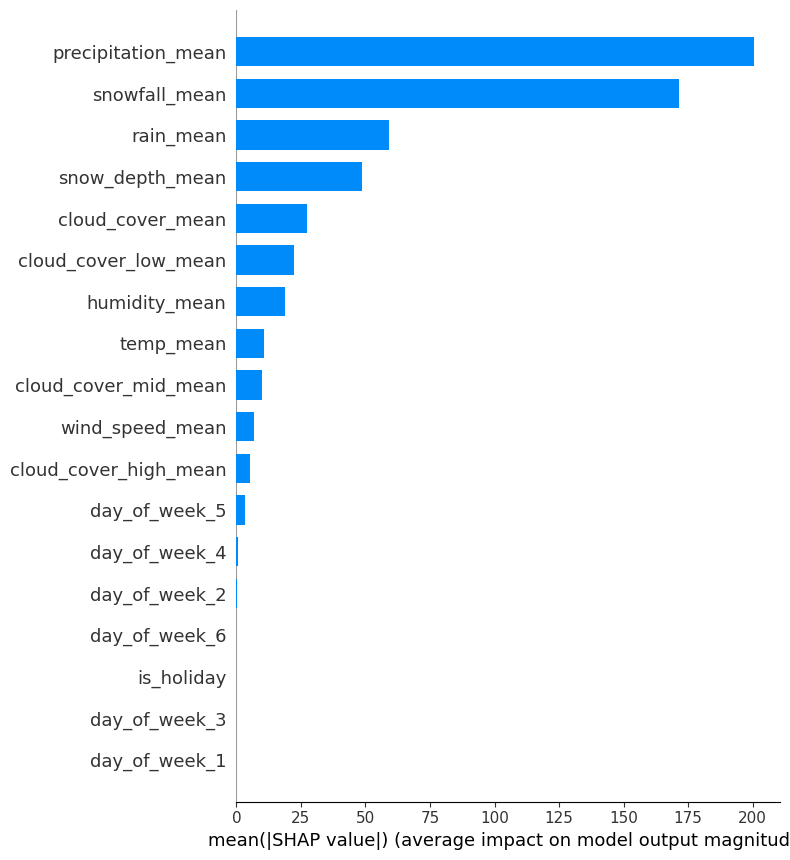

In [13]:
plt.figure()
shap.summary_plot(
    shap_values,
    test_X,
    feature_names=exog_cols,
    plot_type="bar",
    show=True
)

Top feature: precipitation_mean


<Figure size 640x480 with 0 Axes>

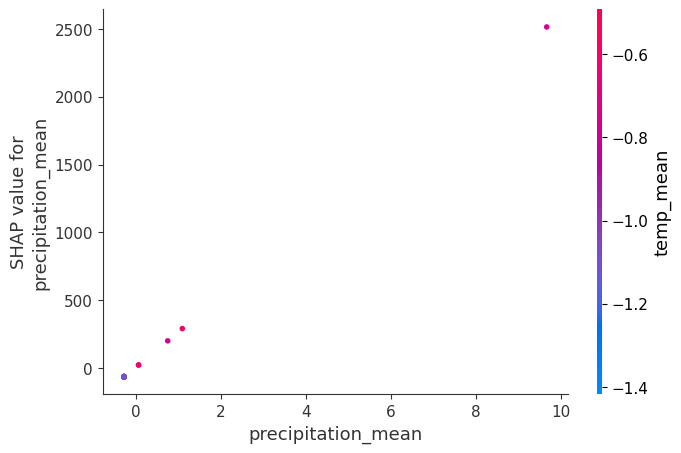

In [14]:
# Dependence plot shows how one feature's value relates to its SHAP value
# Color is automatically set to the feature that most interacts with it
top_feature_idx = np.abs(shap_values).mean(axis=0).argmax()
top_feature = exog_cols[top_feature_idx]
print(f"Top feature: {top_feature}")

plt.figure()
shap.dependence_plot(
    top_feature,
    shap_values,
    test_X,
    feature_names=exog_cols,
    show=True
)